In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
data = pd.read_csv('SGJobData.csv')

In [5]:
data.head()
data.info()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


In [6]:
# Recommended data cleaning workflow
import json

# 1) Remove exact duplicate rows
cleaned = data.drop_duplicates().copy()

# 2) Convert date columns to datetime
for col in ["metadata_expiryDate", "metadata_newPostingDate", "metadata_originalPostingDate"]:
    cleaned[col] = pd.to_datetime(cleaned[col], errors="coerce")

# 3) Parse categories from JSON-like strings

def parse_categories(value):
    if pd.isna(value):
        return []
    try:
        parsed = json.loads(value)
        return [item.get("category") for item in parsed if isinstance(item, dict)]
    except Exception:
        return []

cleaned["categories_parsed"] = cleaned["categories"].apply(parse_categories)

# 4) Clean text columns by stripping whitespace and collapsing repeated spaces
text_cols = [
    "employmentTypes",
    "positionLevels",
    "postedCompany_name",
    "salary_type",
    "status_jobStatus",
    "title"
]
for col in text_cols:
    cleaned[col] = cleaned[col].astype("string").str.strip()
    cleaned[col] = cleaned[col].str.replace(r"\s+", " ", regex=True)

# 5) Fill missing text values with 'Unknown'
for col in ["employmentTypes", "positionLevels", "postedCompany_name", "salary_type", "status_jobStatus", "title"]:
    cleaned[col] = cleaned[col].fillna("Unknown")

# 6) Convert numeric columns to numeric types
numeric_cols = [
    "salary_minimum",
    "salary_maximum",
    "average_salary",
    "metadata_repostCount",
    "metadata_totalNumberJobApplication",
    "metadata_totalNumberOfView",
    "minimumYearsExperience",
    "numberOfVacancies"
]
for col in numeric_cols:
    cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

# 7) Fill missing average salary using the midpoint of min/max salary when possible
cleaned["average_salary"] = cleaned["average_salary"].fillna((cleaned["salary_minimum"] + cleaned["salary_maximum"]) / 2)

# 8) Drop obviously unhelpful column if present
cleaned = cleaned.drop(columns=["occupationId"], errors="ignore")

cleaned.head()
cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1044598 entries, 0 to 1048584
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   categories                          1044597 non-null  object        
 1   employmentTypes                     1044598 non-null  string        
 2   metadata_expiryDate                 1044597 non-null  datetime64[ns]
 3   metadata_isPostedOnBehalf           1044598 non-null  bool          
 4   metadata_jobPostId                  1044597 non-null  object        
 5   metadata_newPostingDate             1044597 non-null  datetime64[ns]
 6   metadata_originalPostingDate        1044597 non-null  datetime64[ns]
 7   metadata_repostCount                1044598 non-null  int64         
 8   metadata_totalNumberJobApplication  1044598 non-null  int64         
 9   metadata_totalNumberOfView          1044598 non-null  int64         

<Figure size 1000x500 with 0 Axes>

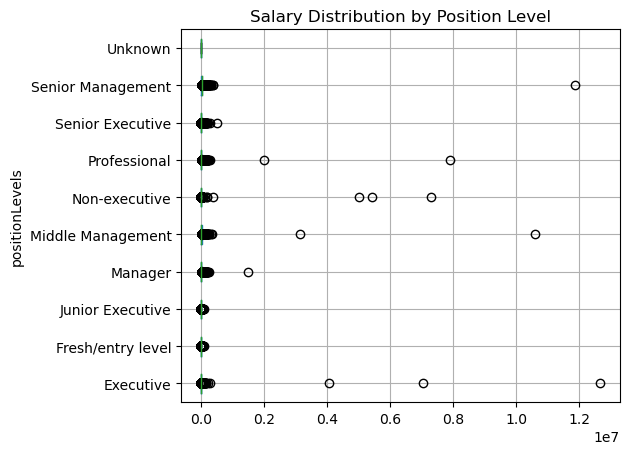

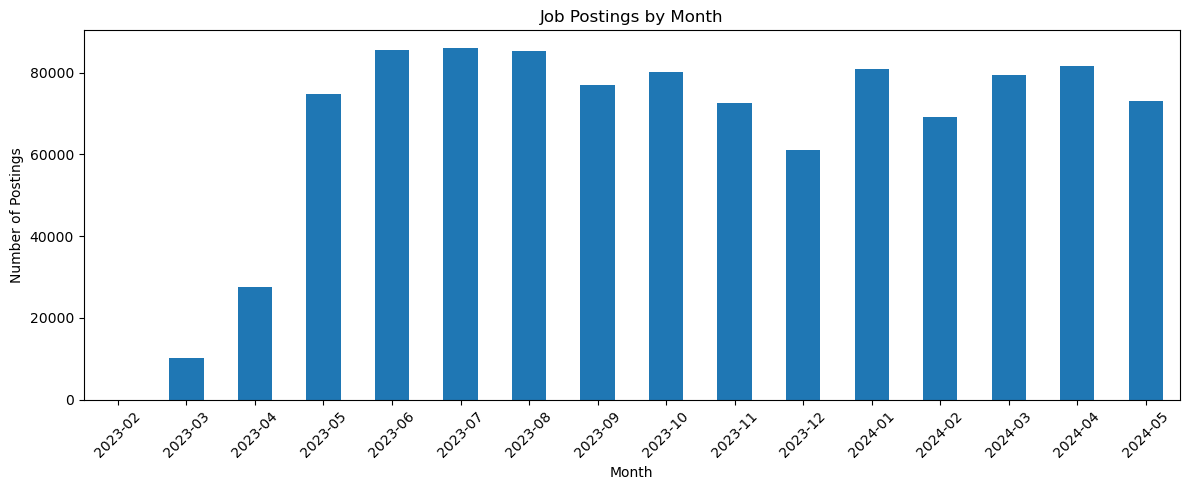

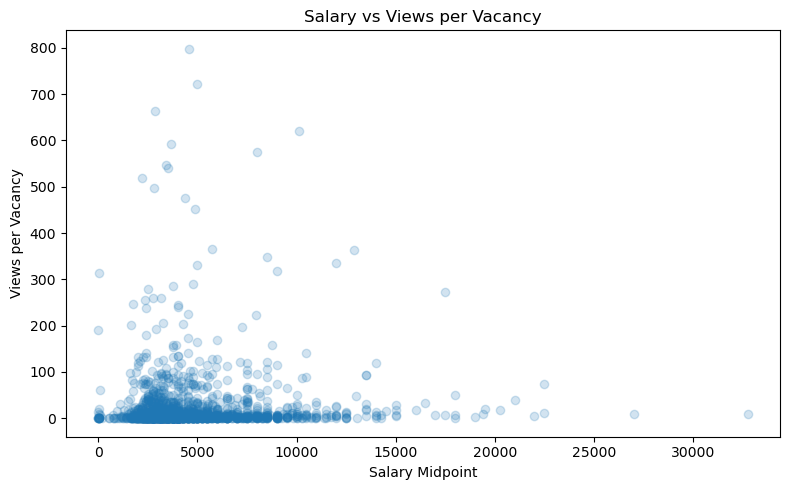

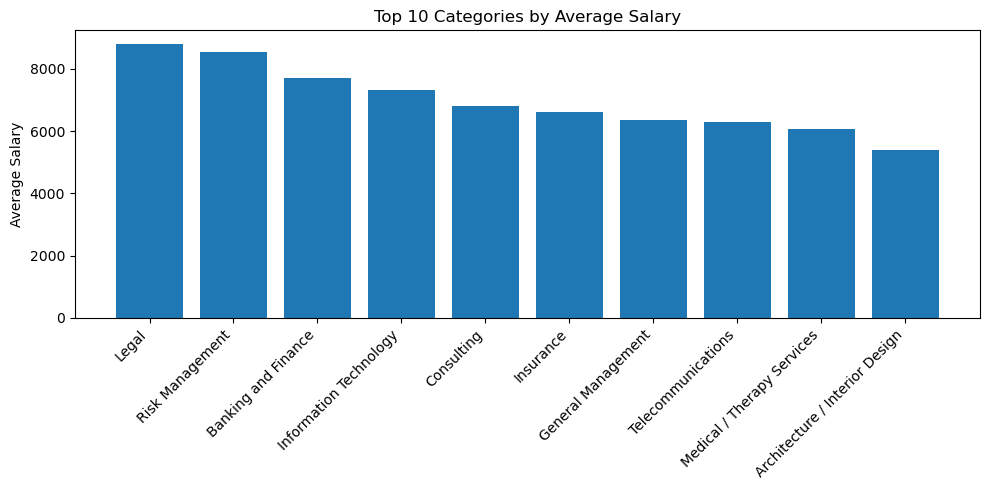

,salary_midpoint,salary_gap,views_per_vacancy,applications_per_vacancy,days_to_expiry,posting_month,is_executive,primary_category
0,2400.0,800,151.0,5.0,30.0,2023-04,True,Environment / Health
1,4750.0,1500,27.5,0.0,30.0,2023-04,True,Information Technology
2,4200.0,800,99.0,7.0,14.0,2023-04,True,Repair and Maintenance
3,7500.0,5000,113.0,6.0,30.0,2023-04,True,Information Technology
4,2900.0,1000,33.0,1.0,30.0,2023-04,True,Admin / Secretarial


In [10]:
# Create business-oriented feature columns and starter visualizations

# Create derived columns
cleaned["salary_midpoint"] = (cleaned["salary_minimum"] + cleaned["salary_maximum"]) / 2
cleaned["salary_gap"] = cleaned["salary_maximum"] - cleaned["salary_minimum"]
cleaned["views_per_vacancy"] = cleaned["metadata_totalNumberOfView"] / cleaned["numberOfVacancies"].replace(0, np.nan)
cleaned["applications_per_vacancy"] = cleaned["metadata_totalNumberJobApplication"] / cleaned["numberOfVacancies"].replace(0, np.nan)
cleaned["days_to_expiry"] = (cleaned["metadata_expiryDate"] - cleaned["metadata_newPostingDate"]).dt.days
cleaned["posting_month"] = cleaned["metadata_newPostingDate"].dt.to_period("M")


# 1) Salary by position level (boxplot)
plt.figure(figsize=(10, 5))
cleaned.boxplot(column="salary_midpoint", by="positionLevels", vert=False, grid=True)
plt.title("Salary Distribution by Position Level")
plt.suptitle("")
plt.tight_layout()
plt.show()

# 2) Number of postings by month
monthly_counts = cleaned["posting_month"].value_counts().sort_index()
plt.figure(figsize=(12, 5))
monthly_counts.plot(kind="bar")
plt.title("Job Postings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) Salary vs engagement (scatter)
plt.figure(figsize=(8, 5))
plt.scatter(cleaned["salary_midpoint"].sample(2000, random_state=42), cleaned["views_per_vacancy"].sample(2000, random_state=42), alpha=0.2)
plt.title("Salary vs Views per Vacancy")
plt.xlabel("Salary Midpoint")
plt.ylabel("Views per Vacancy")
plt.tight_layout()
plt.show()

# 4) Top categories by average salary
top_categories = (
    cleaned.groupby("primary_category")["salary_midpoint"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
plt.bar(top_categories.index, top_categories.values)
plt.title("Top 10 Categories by Average Salary")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.show()

cleaned[["salary_midpoint", "salary_gap", "views_per_vacancy", "applications_per_vacancy", "days_to_expiry", "posting_month", "is_executive", "primary_category"]].head()